In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_u_and_report(I_0_crits):
    for I_0_crit, label in I_0_crits:
        def leaky_integrate_and_fire_model(t, u):
            dudt = (-u + I_0_crit*np.exp(-t/2))/10
            return dudt

        u0 = [0]
        t_span = (0, 50)
        t_eval = np.linspace(0, 50, 1000000)
        solution = scipy.integrate.solve_ivp(fun = leaky_integrate_and_fire_model, t_span = t_span, y0 = u0, t_eval = t_eval, rtol = 1e-10, atol = 1e-10)

        t_peak = solution.t[np.argmax(solution.y[0])]
        u_max = np.max(solution.y[0])

        print("-" * 50)
        print(f"I_0_crit : {I_0_crit}")
        print(f"t_peak: {t_peak}")
        print(f"u_max: {u_max}")
        print("-" * 50)

        plt.plot(solution.t, solution.y[0], label = label)

    plt.axhline(y = 1, color = "red", linestyle = "--", label = "Threshold u_th = 1")
    plt.xlabel("t (ms)")
    plt.ylabel("u (mV)")
    plt.legend()
    plt.show()

--------------------------------------------------
I_0_crit : 5
t_peak: 4.023604023604023
u_max: 0.6687403046431972
--------------------------------------------------
--------------------------------------------------
I_0_crit : 7.476743906106103
t_peak: 4.023604023604023
u_max: 0.9999999995814137
--------------------------------------------------
--------------------------------------------------
I_0_crit : 11.180339887498949
t_peak: 4.023604023604023
u_max: 1.4953487807574712
--------------------------------------------------


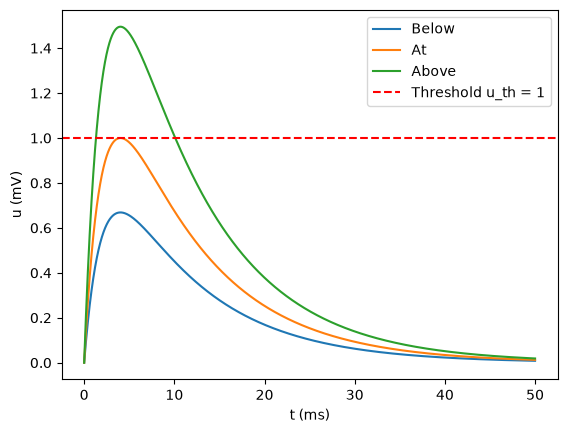

In [3]:
plot_u_and_report([(5, "Below"), (5**(5/4), "At"), (5**(6/4), "Above")])

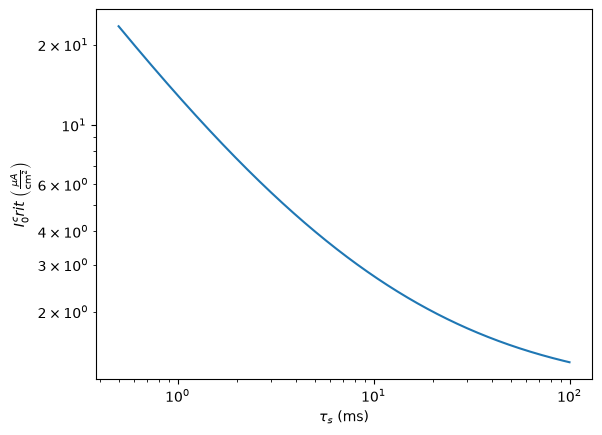

In [4]:
def plot_I_0_crit():
    def calculate_I_0_crit(tau_s):
        return (tau_s/10)**(1/(tau_s/10 - 1))
    tau_s = np.linspace(0.5, 100, 100000)
    I_0_crit = calculate_I_0_crit(tau_s)

    plt.loglog(tau_s, I_0_crit)
    plt.xlabel("$\\tau_s$ (ms)")
    plt.ylabel("$I_0^crit$ $\\left(\\frac{\\mu A}{\\text{cm}^2}\\right)$")
    plt.show()

plot_I_0_crit()